In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('/content/drive/MyDrive/MLProject/notebook/credit_risk_dataset.csv')
data = df.copy()

In [6]:
data.head()

,customer_id,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,CUST_00000,58,Male,Unemployed,58137.751192,115,524.679407,1,171.342369,49,768.877511,9,16,1,539,5,14435.423445,2,0,0,15510.576882,1
1,CUST_00001,48,Male,Self-Employed,26174.922827,32,2635.203357,1,985.607164,1,580.287785,9,1,2,494,5,11263.099341,2,0,0,14819.436498,1
2,CUST_00002,34,Other,Unemployed,75566.837265,14,2334.341061,9,994.310119,42,564.013508,36,5,6,437,3,15017.144132,5,0,0,10909.806507,1
3,CUST_00003,62,Male,Self-Employed,35197.961516,179,2425.384332,10,366.115346,4,838.489200,31,7,7,809,1,12626.138476,2,0,0,500.000000,0
4,CUST_00004,27,Female,Self-Employed,12136.998349,225,10.000000,8,786.752258,16,462.495522,35,16,3,522,1,13576.704320,4,0,0,9514.591618,1


In [7]:
data.drop('customer_id', inplace = True, axis = 1)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   employment_status           5000 non-null   object 
 3   annual_income               5000 non-null   float64
 4   account_age_months          5000 non-null   int64  
 5   avg_monthly_balance         5000 non-null   float64
 6   num_deposits_per_month      5000 non-null   int64  
 7   avg_deposit_amount          5000 non-null   float64
 8   debit_card_usage_frequency  5000 non-null   int64  
 9   debit_card_spending         5000 non-null   float64
 10  mobile_banking_logins       5000 non-null   int64  
 11  online_transfer_frequency   5000 non-null   int64  
 12  atm_withdrawal_frequency    5000 non-null   int64  
 13  credit_score                5000 

In [9]:
data.shape

(5000, 21)

In [10]:
data.size

105000

In [11]:
data['loan_default_history'].value_counts()

,count
loan_default_history,
0,4513
1,487


In [12]:
data['fraud_flag'].value_counts()

,count
fraud_flag,
0,4857
1,143


In [13]:
data['credit_risk'].value_counts()

,count
credit_risk,
1,3829
0,1171


------------------------------------------
- **No null values in the dataset**
- **Need to round the decimal places in float dtype columns to reduce the redundancy in the computations**
- **Need to change the dtypes of binary columns to object type ('loan_default_history', 'fraud_flag', 'credit_risk')**
-----------------------------------------

In [14]:
data['fraud_flag'].nunique()

2

In [15]:
binary_cols = [col for col in data.columns if data[col].nunique() == 2]
data[binary_cols] = data[binary_cols].astype('O')
data[binary_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   loan_default_history  5000 non-null   object
 1   fraud_flag            5000 non-null   object
 2   credit_risk           5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


In [16]:
data.describe()

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,44.666600,49870.073961,121.226800,1500.912691,5.542000,800.663464,24.424800,500.284845,39.028000,9.660600,4.55720,599.328200,2.480800,12173.548537,3.46940,8149.415730
std,14.384312,17831.984829,68.325584,772.243462,3.424118,341.229714,14.395172,245.167842,23.039457,5.858248,2.89109,174.345499,1.698649,5993.358818,2.29332,4309.579471
min,20.000000,10000.000000,3.000000,10.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.00000,300.000000,0.000000,0.000000,0.00000,500.000000
25%,32.000000,37633.483896,62.000000,958.522753,3.000000,559.312932,12.000000,328.342032,19.000000,4.000000,2.00000,447.000000,1.000000,8076.729416,1.00000,4993.481978
50%,45.000000,49682.456590,120.500000,1486.067085,6.000000,802.695763,25.000000,498.752458,39.000000,10.000000,5.00000,597.000000,2.000000,12196.804292,3.00000,8039.116433
75%,57.000000,61964.226233,181.000000,2024.758900,9.000000,1033.796072,37.000000,664.056885,58.000000,15.000000,7.00000,753.000000,4.000000,16279.963090,5.00000,11160.811371
max,69.000000,113793.170197,239.000000,4818.316040,11.000000,1925.380969,49.000000,1379.491843,79.000000,19.000000,9.00000,899.000000,5.000000,32433.862750,7.00000,25622.344659


In [17]:
data.describe(include = 'O')

,gender,employment_status,loan_default_history,fraud_flag,credit_risk
count,5000,5000,5000,5000,5000
unique,3,3,2,2,2
top,Female,Employed,0,0,1
freq,1705,1746,4513,4857,3829


### Rounding to 2 Decimal Places for float dtype columns

In [18]:
float_dtype_cols = [col for col in data.columns if data[col].dtype == np.float64]


In [19]:
data[float_dtype_cols] = data[float_dtype_cols].round(2)

In [20]:
data.head()

,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,58,Male,Unemployed,58137.75,115,524.68,1,171.34,49,768.88,9,16,1,539,5,14435.42,2,0,0,15510.58,1
1,48,Male,Self-Employed,26174.92,32,2635.20,1,985.61,1,580.29,9,1,2,494,5,11263.10,2,0,0,14819.44,1
2,34,Other,Unemployed,75566.84,14,2334.34,9,994.31,42,564.01,36,5,6,437,3,15017.14,5,0,0,10909.81,1
3,62,Male,Self-Employed,35197.96,179,2425.38,10,366.12,4,838.49,31,7,7,809,1,12626.14,2,0,0,500.00,0
4,27,Female,Self-Employed,12137.00,225,10.00,8,786.75,16,462.50,35,16,3,522,1,13576.70,4,0,0,9514.59,1


In [21]:
# avg_deposit_amount          -->    Average value of deposits
# debit_card_usage_frequency  -->    Total debit card transaction count per month
# debit_card_spending         -->    Monthly spending through debit card transactions
# mobile_banking_logins       -->    Number of times customer logs into mobile banking
# online_transfer_frequency   -->    Number of online fund transfers per month
# atm_withdrawal_frequency    -->    ATM withdrawals per month
# total_outstanding_debt      -->    Total amount of unpaid debt

In [22]:
data.duplicated().sum()

np.int64(0)

- **Found no duplicates in the dataset**

In [23]:
data[data.duplicated()]

,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk


- **Checking Missing Values**

In [24]:
data.isnull().sum()/len(data) * 100

,0
age,0.0
gender,0.0
employment_status,0.0
annual_income,0.0
account_age_months,0.0
avg_monthly_balance,0.0
num_deposits_per_month,0.0
avg_deposit_amount,0.0
debit_card_usage_frequency,0.0
debit_card_spending,0.0


- **Checking no.of unique values (cardinality)**

In [25]:
data.nunique()

,0
age,50
gender,3
employment_status,3
annual_income,4930
account_age_months,237
avg_monthly_balance,4805
num_deposits_per_month,12
avg_deposit_amount,4861
debit_card_usage_frequency,50
debit_card_spending,4747


In [26]:
cat_cols = data.select_dtypes(include='O').columns.to_list()
data[cat_cols].head()

,gender,employment_status,loan_default_history,fraud_flag,credit_risk
0,Male,Unemployed,0,0,1
1,Male,Self-Employed,0,0,1
2,Other,Unemployed,0,0,1
3,Male,Self-Employed,0,0,0
4,Female,Self-Employed,0,0,1


In [27]:
for col in cat_cols:
    print(f'\nUnique values in {col} are: \n', data[col].value_counts())


Unique values in gender are: 
 gender
Female    1705
Other     1680
Male      1615
Name: count, dtype: int64

Unique values in employment_status are: 
 employment_status
Employed         1746
Self-Employed    1633
Unemployed       1621
Name: count, dtype: int64

Unique values in loan_default_history are: 
 loan_default_history
0    4513
1     487
Name: count, dtype: int64

Unique values in fraud_flag are: 
 fraud_flag
0    4857
1     143
Name: count, dtype: int64

Unique values in credit_risk are: 
 credit_risk
1    3829
0    1171
Name: count, dtype: int64


- **Checking for class balance in Target Column**

In [28]:
data['credit_risk'].value_counts(normalize=True) * 100   # In percentages

,proportion
credit_risk,
1,76.58
0,23.42


In [29]:
# As there is a class imbalance

at_risk = data[data['credit_risk'] == 1]
at_risk.describe()

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount
count,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000,3829.000000
mean,44.642988,49995.723612,121.871768,1502.344260,5.559937,802.158107,24.345782,502.974730,39.092975,9.638026,4.584487,556.049099,2.487595,12197.670543,4.082267,8195.866075
std,14.419116,17846.025962,67.974010,766.219169,3.427236,339.981674,14.352957,246.548116,22.960332,5.886294,2.896414,170.550394,1.692588,5977.106361,2.209926,4288.500270
min,20.000000,10000.000000,3.000000,10.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.000000,0.000000,0.000000,500.000000
25%,32.000000,37701.810000,62.000000,962.660000,3.000000,563.120000,12.000000,326.520000,19.000000,4.000000,2.000000,413.000000,1.000000,8141.460000,2.000000,5042.680000
50%,45.000000,50085.380000,121.000000,1495.500000,6.000000,805.400000,25.000000,500.340000,39.000000,10.000000,5.000000,525.000000,2.000000,12226.690000,4.000000,8051.180000
75%,57.000000,62464.360000,181.000000,2027.700000,9.000000,1031.080000,37.000000,667.160000,58.000000,15.000000,7.000000,693.000000,4.000000,16317.030000,6.000000,11185.450000
max,69.000000,113793.170000,239.000000,4818.320000,11.000000,1925.380000,49.000000,1379.490000,79.000000,19.000000,9.000000,899.000000,5.000000,31088.020000,7.000000,25622.340000


In [30]:
no_risk = data[data['credit_risk'] == 0]
no_risk.describe()

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_application_amount
count,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000
mean,44.743809,49459.217660,119.117848,1496.231716,5.483348,795.776029,24.683177,491.489231,38.815542,9.734415,4.467976,740.844577,2.458582,12094.673433,1.465414,7997.529898
std,14.275768,17787.405673,69.450307,791.937172,3.414702,345.380318,14.535528,240.493354,23.304931,5.767460,2.873032,92.362865,1.718860,6048.094569,1.115297,4376.206207
min,20.000000,10000.000000,3.000000,10.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,580.000000,0.000000,0.000000,0.000000,500.000000
25%,33.000000,37490.155000,57.000000,945.955000,3.000000,547.215000,12.000000,334.235000,19.000000,5.000000,2.000000,660.000000,1.000000,7809.735000,0.000000,4750.755000
50%,45.000000,48821.830000,117.000000,1466.780000,5.000000,792.030000,24.000000,492.500000,38.000000,10.000000,4.000000,746.000000,2.000000,12065.850000,1.000000,8000.360000
75%,57.000000,60677.745000,182.000000,2009.345000,8.000000,1035.745000,37.000000,652.565000,58.000000,15.000000,7.000000,819.000000,4.000000,16198.590000,2.000000,10992.725000
max,69.000000,105215.040000,239.000000,4113.780000,11.000000,1905.630000,49.000000,1237.250000,79.000000,19.000000,9.000000,899.000000,5.000000,32433.860000,3.000000,21071.930000


<Axes: xlabel='credit_risk', ylabel='age'>

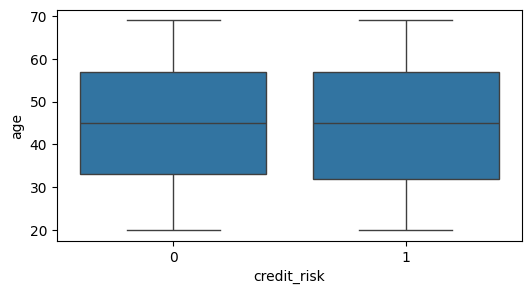

In [31]:
plt.figure(figsize=(6,3))
sns.boxplot(x = 'credit_risk', y = 'age', data=data)

<Axes: xlabel='credit_risk', ylabel='credit_score'>

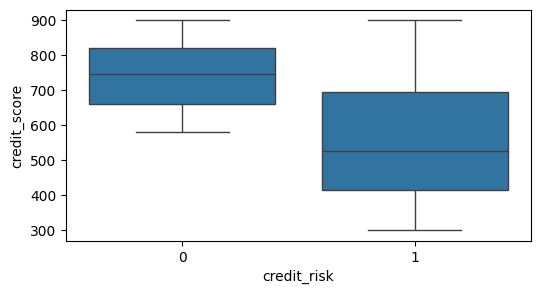

In [32]:
plt.figure(figsize=(6,3))
sns.boxplot(x = 'credit_risk', y = 'credit_score', data=data)

# Exploratory Data Analysis

### Univariate Analysis

In [33]:
def univariate_num_analysis(data, col):

  # Non-visual analysis
  series = data[col]
  print('Non-Visual Analysis:\n')
  print(series.agg(['min', 'max', 'mean', 'median', 'std', 'var', 'skew', 'kurt']))
  print('-'*20)

  # Visual Analysis
  fig, axes = plt.subplots(1, 3, figsize=(8,3), layout = 'constrained')
  fig.suptitle('Continuous Data Distributions')

  axes[0].set_title('Histogram')
  sns.histplot(data[col], ax = axes[0])

  axes[1].set_title('Kde Plot')
  sns.kdeplot(data[col], ax = axes[1])

  axes[2].set_title('Box Plot')
  sns.boxplot(data[col], ax = axes[2])

  fig.show()


Non-Visual Analysis:

min        20.000000
max        69.000000
mean       44.666600
median     45.000000
std        14.384312
var       206.908426
skew       -0.018924
kurt       -1.179653
Name: age, dtype: float64
--------------------


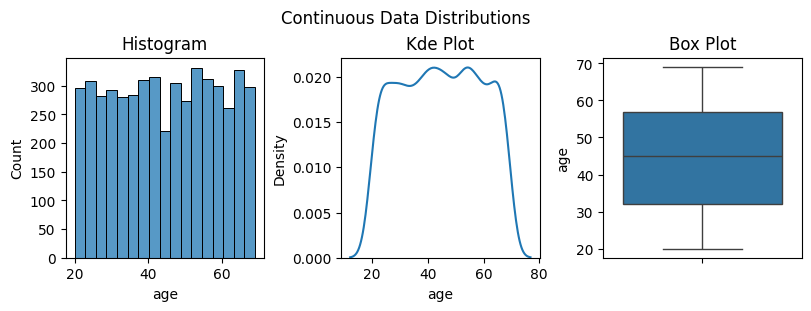

In [34]:
univariate_num_analysis(data, 'age')

Non-Visual Analysis:

min         300.000000
max         899.000000
mean        599.328200
median      597.000000
std         174.345499
var       30396.352955
skew          0.017337
kurt         -1.225593
Name: credit_score, dtype: float64
--------------------


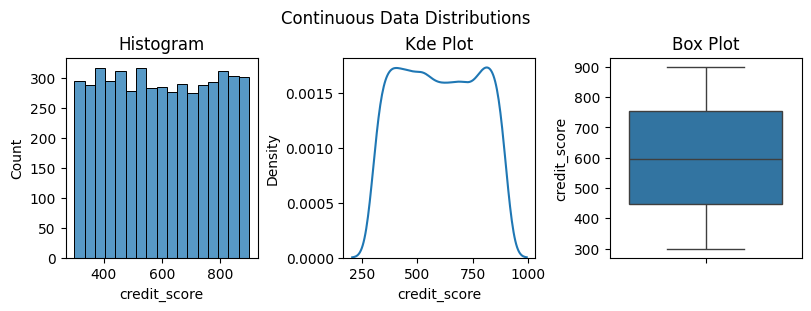

In [35]:
univariate_num_analysis(data, 'credit_score')

Non-Visual Analysis:

min           20.000000
max         1925.380000
mean         800.663424
median       802.695000
std          341.229691
var       116437.702296
skew           0.068300
kurt          -0.234593
Name: avg_deposit_amount, dtype: float64
--------------------


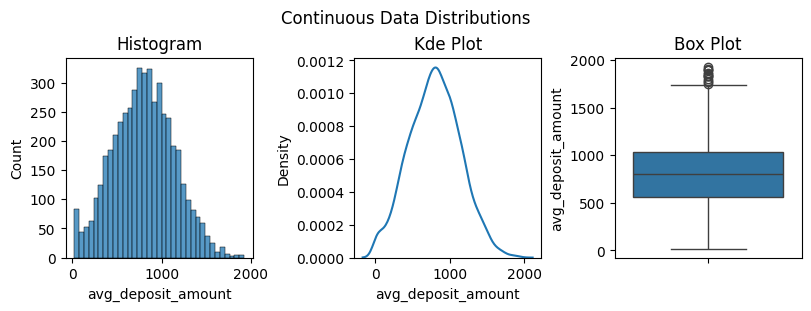

In [36]:
univariate_num_analysis(data, 'avg_deposit_amount')

Non-Visual Analysis:

min       0.000000
max       5.000000
mean      2.480800
median    2.000000
std       1.698649
var       2.885408
skew      0.008936
kurt     -1.266367
Name: num_open_loans, dtype: float64
--------------------


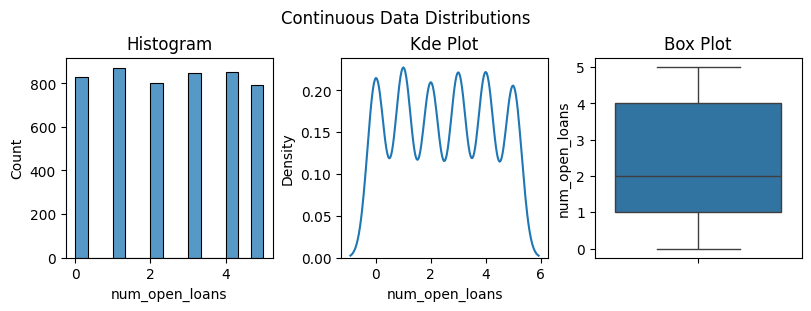

In [37]:
univariate_num_analysis(data, 'num_open_loans')

Non-Visual Analysis:

min       0.000000
max       7.000000
mean      3.469400
median    3.000000
std       2.293320
var       5.259316
skew      0.007009
kurt     -1.233282
Name: late_payment_count, dtype: float64
--------------------


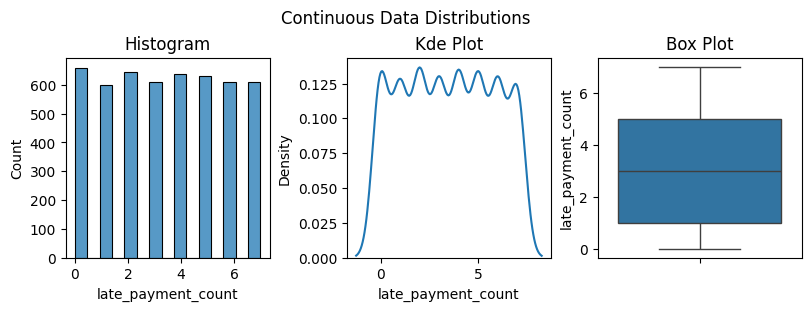

In [38]:
univariate_num_analysis(data, 'late_payment_count')

Non-Visual Analysis:

min       5.000000e+02
max       2.562234e+04
mean      8.149416e+03
median    8.039115e+03
std       4.309579e+03
var       1.857248e+07
skew      2.193212e-01
kurt     -3.143151e-01
Name: loan_application_amount, dtype: float64
--------------------


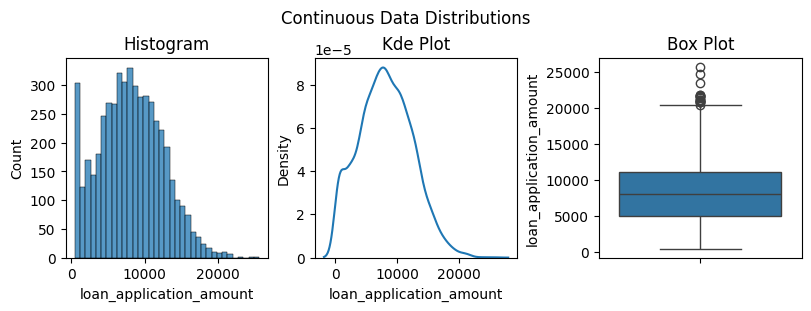

In [39]:
univariate_num_analysis(data, 'loan_application_amount')

In [48]:
def univariate_cat_analysis(data, col):

  print('Non-Visual Analysis\n')
  print(f'Value Counts for column:', col)
  print(data[col].value_counts())
  print('-'*20)

  fig, axes = plt.subplots(1, 2, figsize=(8,3), layout='constrained')
  fig.suptitle('Univariate Categorical Analysis')

  axes[0].set_title('Bar Plot')
  sns.countplot(x=data[col], ax = axes[0])

  axes[1].set_title('Pie Chart')
  data[col].value_counts().plot(kind='pie', ax = axes[1], autopct='%2.1f%%')

  fig.show()

Non-Visual Analysis

Value Counts for column: loan_default_history
loan_default_history
0    4513
1     487
Name: count, dtype: int64
--------------------


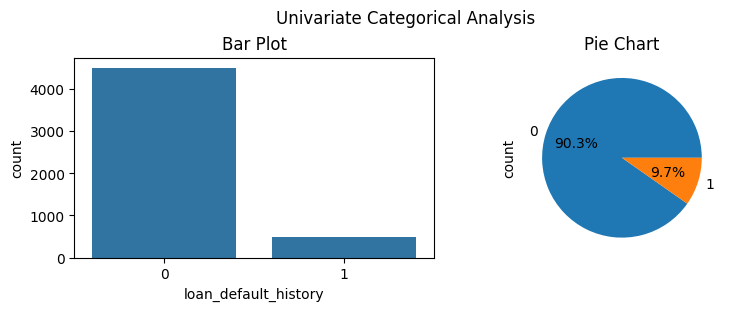

In [49]:
univariate_cat_analysis(data, 'loan_default_history')

Non-Visual Analysis

Value Counts for column: employment_status
employment_status
Employed         1746
Self-Employed    1633
Unemployed       1621
Name: count, dtype: int64
--------------------


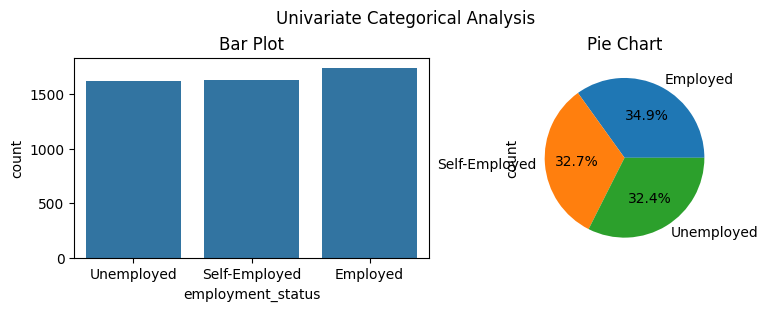

In [50]:
univariate_cat_analysis(data, 'employment_status')

Non-Visual Analysis

Value Counts for column: gender
gender
Female    1705
Other     1680
Male      1615
Name: count, dtype: int64
--------------------


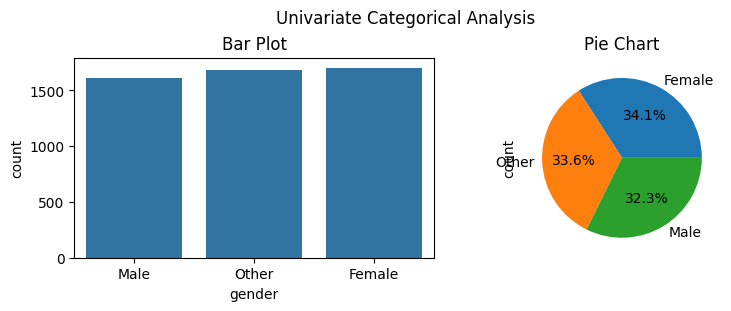

In [51]:
univariate_cat_analysis(data, 'gender')

Non-Visual Analysis

Value Counts for column: fraud_flag
fraud_flag
0    4857
1     143
Name: count, dtype: int64
--------------------


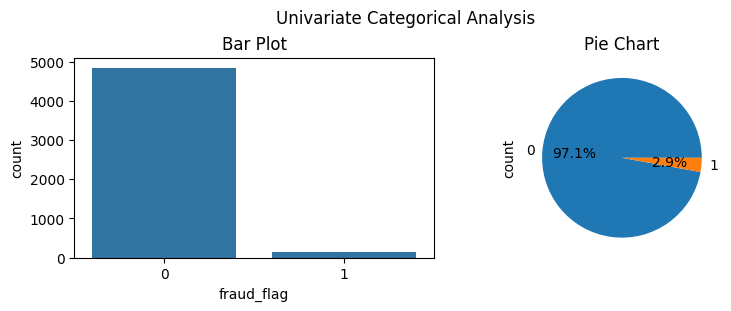

In [52]:
univariate_cat_analysis(data, 'fraud_flag')

Non-Visual Analysis

Value Counts for column: credit_risk
credit_risk
1    3829
0    1171
Name: count, dtype: int64
--------------------


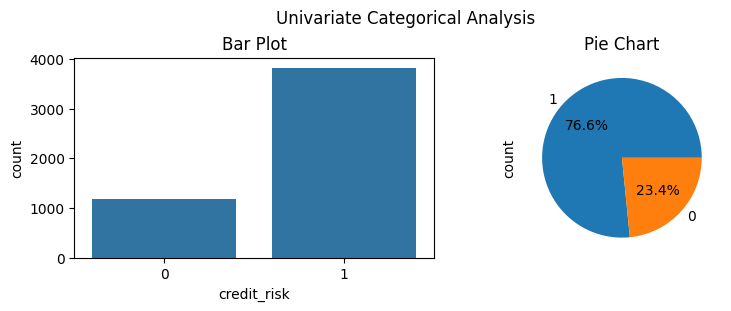

In [53]:
univariate_cat_analysis(data, 'credit_risk')

## Bivariate Analysis

#### Numerical vs Numerical

In [68]:
def numerical_bivariate_analysis(data, col1, col2):

  print('Non-Visual Analysis:')
  print(f'Correlation b/w {col1} and {col2}: ', data[col1].corr(data[col2]))
  print(f'Covariance b/w {col1} and {col2}: ', data[col1].cov(data[col2]))

  plt.figure(figsize=(6,3))
  sns.scatterplot(x=data[col1], y=data[col2], data = data)
  plt.title(f'Scatter Plot: {col1} vs {col2}')
  plt.xlabel(col1)
  plt.ylabel(col2)


Non-Visual Analysis:
Correlation b/w age and credit_score:  -0.002963372624673643
Covariance b/w age and credit_score:  -7.43166445289058


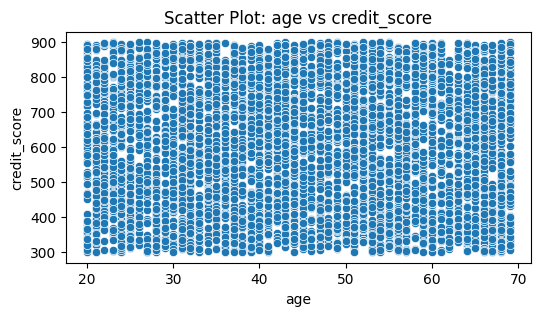

In [69]:
numerical_bivariate_analysis(data, 'age', 'credit_score')

- The scatter plot reveals a Uniform Distribution across all age groups.
- With a correlation coefficient of nearly 0, we can conclude that Age holds no predictive power for Credit Score in this population.
- This suggests that financial behavior in this dataset is driven by factors other than the life stage of the individual.

Non-Visual Analysis:
Correlation b/w num_open_loans and credit_score:  -0.017257435494722684
Covariance b/w num_open_loans and credit_score:  -5.110820724144831


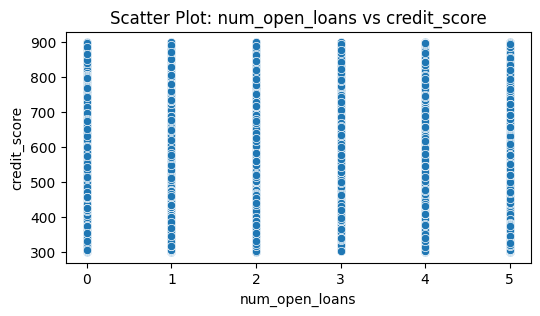

In [75]:
numerical_bivariate_analysis(data, 'num_open_loans', 'credit_score')

- The data indicates that the number of open loans is not a significant feature for predicting credit scores.
- Regardless of whether a customer has zero loans or five, the distribution of credit scores remains identical.
- We cannot conclude that having more loans negatively (or positively) impacts the credit score based on this sample.

Non-Visual Analysis:
Correlation b/w late_payment_count and credit_score:  -0.014307584554416546
Covariance b/w late_payment_count and credit_score:  -5.720601200240049


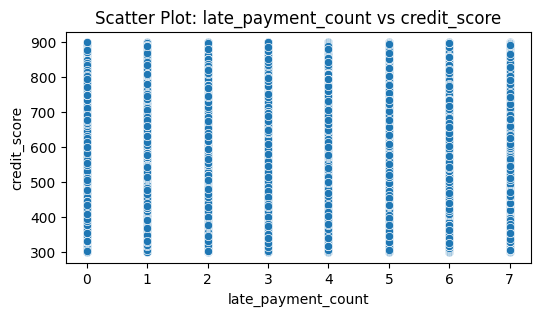

In [77]:
numerical_bivariate_analysis(data, 'late_payment_count', 'credit_score')

- based strictly on the data we have here, the story is the same as before.

- Surprisingly, our data shows that the number of late payments does not correlate with a customer's credit score.
- A customer with zero late payments is just as likely to have a poor score as someone with seven.
- This suggests that in this specific dataset, late payments are not a 'red flag' for creditworthiness, and we should look for other features—like total debt or annual income—to find the real drivers of the score.

In [78]:
[col for col in data.columns if data[col].dtype == int]

['age',
 'account_age_months',
 'num_deposits_per_month',
 'debit_card_usage_frequency',
 'mobile_banking_logins',
 'online_transfer_frequency',
 'atm_withdrawal_frequency',
 'credit_score',
 'num_open_loans',
 'late_payment_count']

## Categorical vs Categorical

In [101]:
def cat_bivariate_analysis(data, col1, col2=data['credit_risk']):

  plt.figure(figsize=(8, 4))
  ax = sns.countplot(x = data[col1], hue = col2, data = data)
  plt.title(f'Credit Risk by {col1}')

  # Adding count labels on top of each bar
  for container in ax.containers:
      ax.bar_label(container, label_type = 'edge', fontsize = 9, padding = 3)

  plt.tight_layout()
  plt.show()

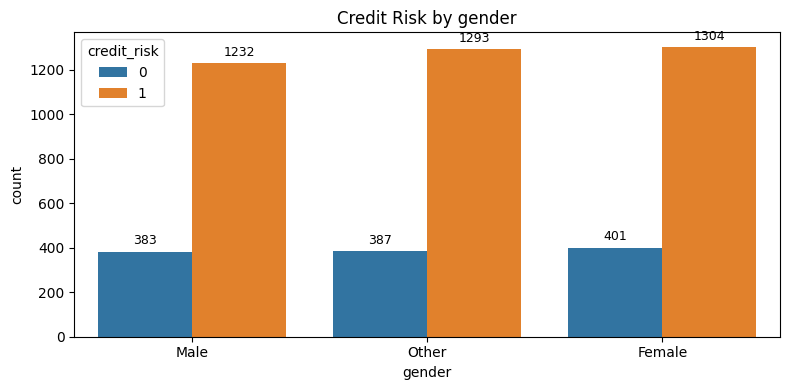

In [102]:
cat_bivariate_analysis(data, 'gender')

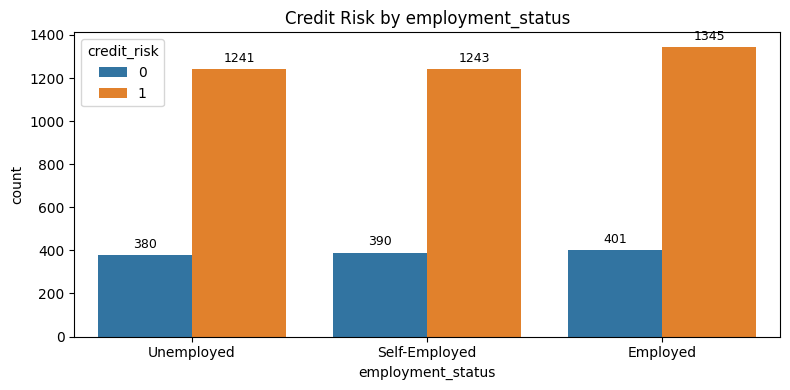

In [105]:
cat_bivariate_analysis(data, 'employment_status')

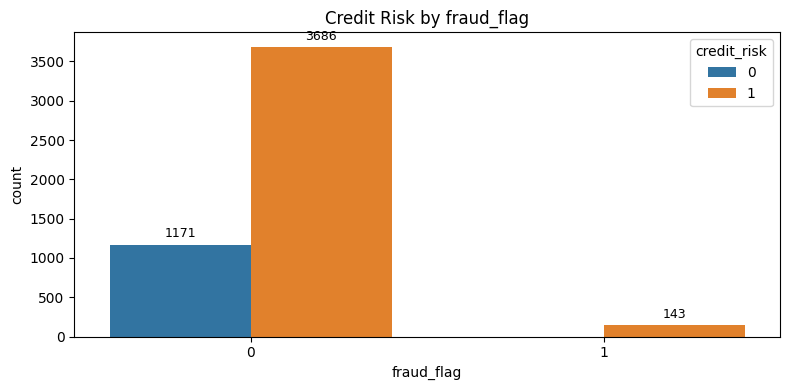

In [106]:
cat_bivariate_analysis(data, 'fraud_flag')

In [108]:
data.select_dtypes(include='O').columns

Index(['gender', 'employment_status', 'loan_default_history', 'fraud_flag',
       'credit_risk'],
      dtype='object')

In [109]:
data

,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,58,Male,Unemployed,58137.75,115,524.68,1,171.34,49,768.88,9,16,1,539,5,14435.42,2,0,0,15510.58,1
1,48,Male,Self-Employed,26174.92,32,2635.20,1,985.61,1,580.29,9,1,2,494,5,11263.10,2,0,0,14819.44,1
2,34,Other,Unemployed,75566.84,14,2334.34,9,994.31,42,564.01,36,5,6,437,3,15017.14,5,0,0,10909.81,1
3,62,Male,Self-Employed,35197.96,179,2425.38,10,366.12,4,838.49,31,7,7,809,1,12626.14,2,0,0,500.00,0
4,27,Female,Self-Employed,12137.00,225,10.00,8,786.75,16,462.50,35,16,3,522,1,13576.70,4,0,0,9514.59,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,51,Other,Self-Employed,60489.15,237,571.82,11,837.42,48,772.99,25,14,5,373,5,6099.14,3,0,0,3105.13,1
4996,65,Female,Self-Employed,17499.77,147,1080.41,10,528.62,48,344.91,17,5,1,820,5,19972.41,6,1,0,9965.29,1
4997,66,Other,Employed,68017.36,36,1518.60,0,874.25,27,436.46,65,17,2,746,4,19839.56,1,0,0,14663.25,0
4998,67,Male,Unemployed,42615.08,126,779.13,6,520.14,21,521.26,39,16,4,791,3,15017.90,7,0,0,10562.04,1


In [111]:
# Exporting the cleaned dataset

data.to_csv('credit_risk_dataset_cleaned.csv', index=False)